# Week 4 - Stereo calibration, rectification and disparity

Group 22 - Goal is to go from two uncalibrated cameras to a disparity map, where each pixel says how far
a point shifted between the two views (which is inversely proportional to depth).

Four stages, with each one being a precondition for the next. More specifically, calibrate each camera, calibrate the pair, rectify and then block match. We run it on two datasets to see how much the result depends on the
camera rather than on our code.

In [43]:
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt 

## Calibration

We show the cameras an object we already know the geometry of (a checkerboard) and solve for the
camera parameters that explain the images. Each pair gives object points (corners in mm on the
board) and image points (where they landed in px).

We calibrate each camera separately first, then only solve for the pose between them. The reason
is in the comment on the flag below. Additionally, it is a function because we reuse it on the second dataset.

In [44]:
def calibrate_stereo(nb_vertical, nb_horizontal, dataset):
    # Known corner positions on the flat board, so Z = 0. The pattern counts internal corners, not
    # squares, and (nb_vertical, nb_horizontal) is used as (columns, rows)
    objp = np.zeros((nb_horizontal * nb_vertical, 3), np.float32)
    objp[:,:2] = np.mgrid[0:nb_vertical, 0:nb_horizontal].T.reshape(-1,2)
    
    # Square size in mm, so corner (c, r) becomes (33.6*c, 33.6*r, 0). This is what puts T and any
    # 3D coordinates we derive later in mm rather than in squares
    objp = objp * 33.6
    # The same index in all three lists refers to the same physical corner
    objpoints = []
    img_points_left, img_points_right = [], []

    # sorted() so left-0000 pairs with right-0000
    images_left = sorted(glob.glob(f'{dataset}/left*.png'))
    images_right = sorted(glob.glob(f'{dataset}/right*.png'))

    # Stop refining a corner after 30 iterations or once it moves less than 0.001 px
    criteria = criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

    assert len(images_left) == len(images_right)
    processed = 0

    try:
        for img_left, img_right in zip(images_left, images_right):
            img_left = cv2.imread(img_left)
            img_right = cv2.imread(img_right)

            gray_l = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
            gray_r = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

            retl, cornersl = cv2.findChessboardCorners(gray_l, (nb_vertical, nb_horizontal))
            retr, cornersr = cv2.findChessboardCorners(gray_r, (nb_vertical, nb_horizontal))

            # Both cameras must see the board
            if retl and retr:
                # Corner detection is only pixel-accurate and this refines it to sub-pixel
                cornersl = cv2.cornerSubPix(gray_l, cornersl, (10, 10), (-1, -1), criteria)
                cornersr = cv2.cornerSubPix(gray_r, cornersr, (10,10), (-1,-1), criteria)

                objpoints.append(objp)
                img_points_left.append(cornersl)
                img_points_right.append(cornersr)
                processed += 1
                
                # For display reasons
                # Draw the detected corners on both images
                img_left = cv2.drawChessboardCorners(img_left, (nb_vertical, nb_horizontal), cornersl, retl)
                img_right = cv2.drawChessboardCorners(img_right, (nb_vertical, nb_horizontal), cornersr, retr)

                # Display each successful pair
                cv2.imshow("Left image", img_left)
                cv2.imshow("Right image", img_right)
                cv2.waitKey(50)

    finally:
        cv2.destroyAllWindows()

        # process the window-closing events
        for _ in range(10):
            cv2.waitKey(1)
    print(f"Corners found in {processed} image pairs")

    
    # numpy is (h, w) while OpenCV wants (w, h)
    img_size = gray_l.shape[::-1]

    # Estimate each camera's intrinsics K = [[fx, 0, cx], [0, fy, cy], [0, 0, 1]] and its distortion
    # Undistorted, a 3D point in camera coordinates projects to u = fx*X/Z + cx, v = fy*Y/Z + cy
    retl, mtx_l, dist_l, _, _ = cv2.calibrateCamera(objpoints, img_points_left, img_size, None, None)
    retr, mtx_r, dist_r, _, _ = cv2.calibrateCamera(objpoints, img_points_right, img_size, None, None)

    stereo_criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)
    # Keep the intrinsics we just solved and let the stereo step only find R and T 
    # This way there are fewer free parameters and a more stable fit
    stereo_flags = cv2.CALIB_FIX_INTRINSIC

    ret_stereo, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F = cv2.stereoCalibrate(
        objpoints, img_points_left, img_points_right,
        mtx_l, dist_l, mtx_r, dist_r, img_size,
        criteria=stereo_criteria, flags=stereo_flags
    )

    return ret_stereo, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F

def get_image_shape(dataset):
    img = cv2.imread(f'{dataset}/left-0000.png', cv2.IMREAD_GRAYSCALE)
    return img.shape[::-1]

### Dataset 1: RealSense

RMS is the reprojection error in px. We project the known corners back with our model and see how far
off they land. 0.19 px over 76 pairs is a good fit. The two camera matrices also come out nearly
identical, which is what two sensors in one housing should look like.

In [45]:
ds = '../data/week_4/rs'
ret_stereo, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F = calibrate_stereo(9, 6, ds)
print(f"Overall RMS: {ret_stereo}")
shape = get_image_shape(ds)

# alpha=1 keeps all pixels (black borders), roi marks the part with real data
new_camera_matrix_l, roi_l = cv2.getOptimalNewCameraMatrix(mtx_l, dist_l, shape, 1, shape)
new_camera_matrix_r, roi_r = cv2.getOptimalNewCameraMatrix(mtx_r, dist_r, shape, 1, shape)


print(f"New camera matrix l {new_camera_matrix_l}\n roi_l {roi_l}")
print(f"New camera matrix r {new_camera_matrix_r}\n roi_l {roi_r}")

Corners found in 76 image pairs
Overall RMS: 0.19408537681840937
New camera matrix l [[370.16046024   0.         324.27330662]
 [  0.         370.64476135 245.81367319]
 [  0.           0.           1.        ]]
 roi_l (3, 4, 633, 473)
New camera matrix r [[369.97971538   0.         323.49942997]
 [  0.         370.81085723 246.58291997]
 [  0.           0.           1.        ]]
 roi_l (4, 4, 632, 473)


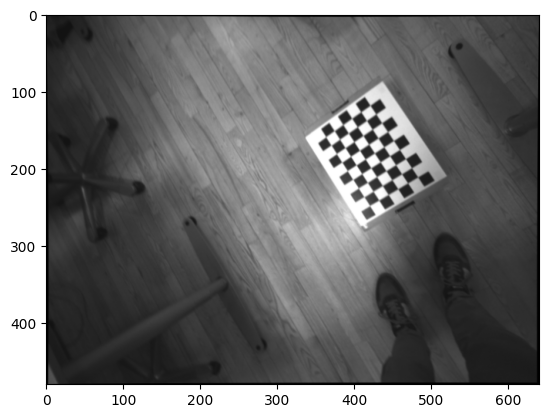

In [46]:
img_left = cv2.imread(f'{ds}/left-0000.png', cv2.IMREAD_GRAYSCALE)
img_right = cv2.imread(f'{ds}/right-0000.png', cv2.IMREAD_GRAYSCALE)

dst_l = cv2.undistort(img_left, mtx_l, dist_l, None, new_camera_matrix_l)
dst_r = cv2.undistort(img_right, mtx_r, dist_r, None, new_camera_matrix_r)

plt.imshow(dst_l, cmap='gray')

## Rectification

Without it, the match for a pixel lies somewhere along a slanted epipolar line. Rectification
rotates both image planes until the epipolar lines themselves are the image rows, so the search below is
1D along a row instead of 2D over the image.

In [47]:

R1, R2, P1, P2, Q, roi_l, roi_r = cv2.stereoRectify(
    mtx_l, dist_l, mtx_r, dist_r, shape, R, T,
    flags=cv2.CALIB_ZERO_DISPARITY, alpha=0
)

# The maps are fixed for a given rig, so build them once and remap each frame
map_l_x, map_l_y = cv2.initUndistortRectifyMap(mtx_l, dist_l, R1, P1, shape, cv2.CV_32FC1)
map_r_x, map_r_y = cv2.initUndistortRectifyMap(mtx_r, dist_r, R2, P2, shape, cv2.CV_32FC1)

In [48]:
rectified_l = cv2.remap(img_left, map_l_x, map_l_y, cv2.INTER_LINEAR)
rectified_r = cv2.remap(img_right, map_r_x, map_r_y, cv2.INTER_LINEAR)

We check that the same feature must be cut by the same green line in both halves. If not, the
rectification is wrong and every disparity after it is meaningless

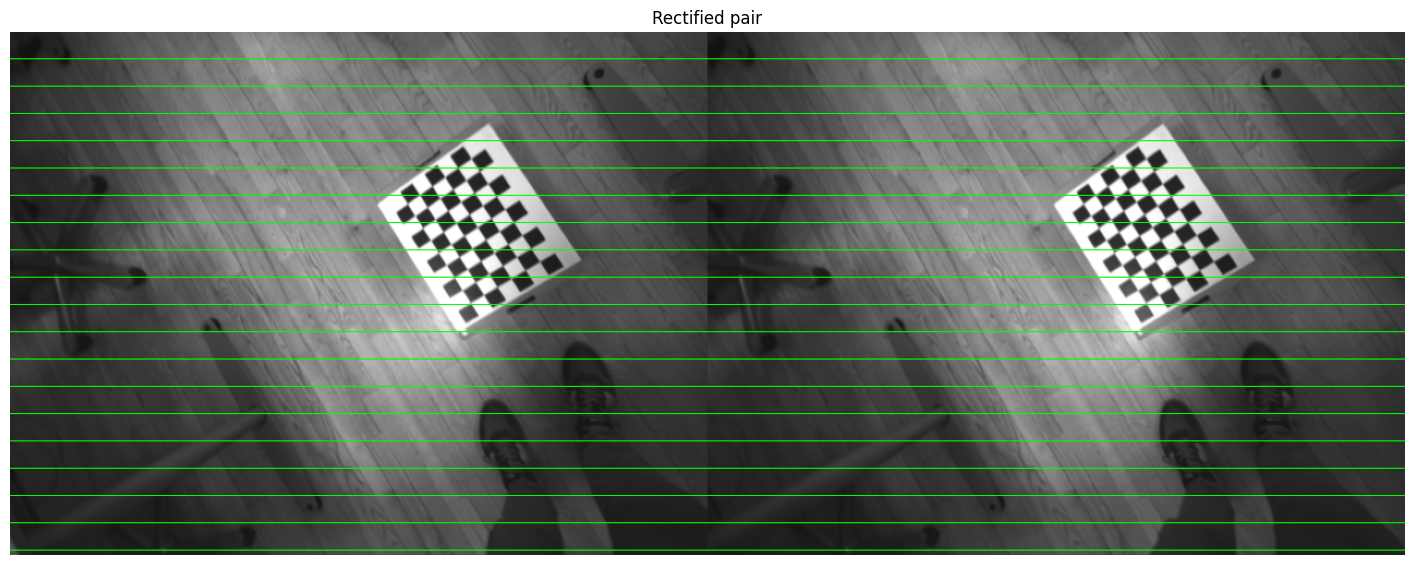

In [49]:
stacked = np.hstack((rectified_l, rectified_r))
stacked_bgr = cv2.cvtColor(stacked, cv2.COLOR_GRAY2BGR)

for y in range(0, stacked_bgr.shape[0], 25):
    cv2.line(stacked_bgr, (0, y), (stacked_bgr.shape[1], y), (0, 255, 0), 1)

plt.figure(figsize=(18, 9))
plt.imshow(stacked_bgr[..., [2, 1, 0]])
plt.title("Rectified pair")
plt.axis('off')
plt.show()

## Disparity by block matching

For each pixel in the left image, take a 7x7 template, slide it along the matching row of the right
image and score each position by sum of absolute differences. We need the lowest score and the column shift is
the disparity.

SAD assumes both cameras see the same brightness. The loops are `O(rows * cols^2)` in pure Python, hence the minutes and the progress print.

In [58]:
def absSumDiffImage(img1, img2):
    # if img1.shape != img2.shape:
    #     raise ValueError("Images must have the same dimensions!")
    # int16 because uint8 would wrap around on a negative difference
    return np.sum(np.abs(img1.astype(np.int16) - img2.astype(np.int16)))

def findMatch(img_slice, template):
    # Count how many columns img_slice has
    span = img_slice.shape[1]
    # Create an array of zeros, one for each column --> Each value will have the matching score for that position
    difs_span = np.zeros(span)

    # Assuming height is always 7, with 4 as middle pixel
    for i in range(span):
        # skip centres where the 7-column block would go outside the image
        if i < 3 or i > span -4:
            # inf, not 0, so argmin can never pick an out-of-bounds position
            difs_span[i] = np.inf
            continue

        # Selecting all rows and 7 columns centred at column i (the end index i+4 is excluded)
        img_current = img_slice[:,i-3:i+4]
        
        # Calculate the sum of absolute differences between this block and the template: a lower score means a better match in pixel values
        difs_span[i] = float(absSumDiffImage(img_current, template))
    
    # Returns index for which the dif was lowest ie best match
    return np.argmin(difs_span) 


def disparity(img_left, img_right):
    # movement_map = np.zeros_like(img_left) 
    # The movement map should only be in 2D
    movement_map = np.zeros_like(img_left, dtype=np.float32)
    print(img_left.shape, img_right.shape)
    rows = movement_map.shape[0]
    columns = movement_map.shape[1]
    
    for i in range(rows):
        if i%10 == 0:
            print("Rows are", int((i/rows)*100),r"% finished")
        for j in range(columns):
            if (i < 3 or i > rows -4) or (j < 3 or j > columns -4):
                # We assume no movement on the edges since we cannot compute it
                movement_map[i,j] = 0
                continue

            current_template = img_left[i-3:i+4,j-3:j+4]
            # movement_map[i,j] = findMatch(img_right[i-3:i+4,:],current_template) - j 
            movement_map[i,j] = j - findMatch(img_right[i-3:i+4,:],current_template)
    # subtract j as it is the current column index and we want movement not position of match 
    print(f"Rows are 100 % finished")
    return movement_map

In [51]:
def plot_disparity_views(result, clip=100):
    raw = result
    clipped = np.where((result > clip) | (result < -clip), 0, result)
    positive = np.where(result < 0, 0, result)
    negative = np.where(result > 0, 0, result)
    negative_clipped = np.where((result > 0) | (result < -clip), 0, result)

    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 4))

    im1 = ax1.imshow(raw, cmap='viridis')
    ax1.set_title(f"Raw disparity\navg={raw.mean():.2f}", fontsize=9)
    ax1.axis('off')
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    im2 = ax2.imshow(clipped, cmap='viridis')
    ax2.set_title(f"Clipped to +/-{clip}\navg={clipped.mean():.2f}", fontsize=9)
    ax2.axis('off')
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    im3 = ax3.imshow(positive, cmap='viridis')
    ax3.set_title(f"Positive movement only\navg={positive.mean():.2f}", fontsize=9)
    ax3.axis('off')
    fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    im4 = ax4.imshow(negative, cmap='viridis')
    ax4.set_title(f"Negative movement only\navg={negative.mean():.2f}", fontsize=9)
    ax4.axis('off')
    fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

    im5 = ax5.imshow(negative_clipped, cmap='viridis')
    ax5.set_title(f"Negative movement, clipped to -{clip}\navg={negative_clipped.mean():.2f}", fontsize=9)
    ax5.axis('off')
    fig.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)

    fig.suptitle("Disparity map views")
    plt.tight_layout()
    plt.show()

### Dataset 1 results

The positive view recovers the scene structure. Negative values cannot occur for a correct match,
so they mark where the matcher failed to make good detections like on untextured surfaces, where every candidate along the row scores the same and argmin picks noise. Same for the huge positive values, which is why we clip at
100 px.

To counteract that we restrict the search to a plausible disparity range (kills most of the noise and most of the runtime), then a left-right consistency check.

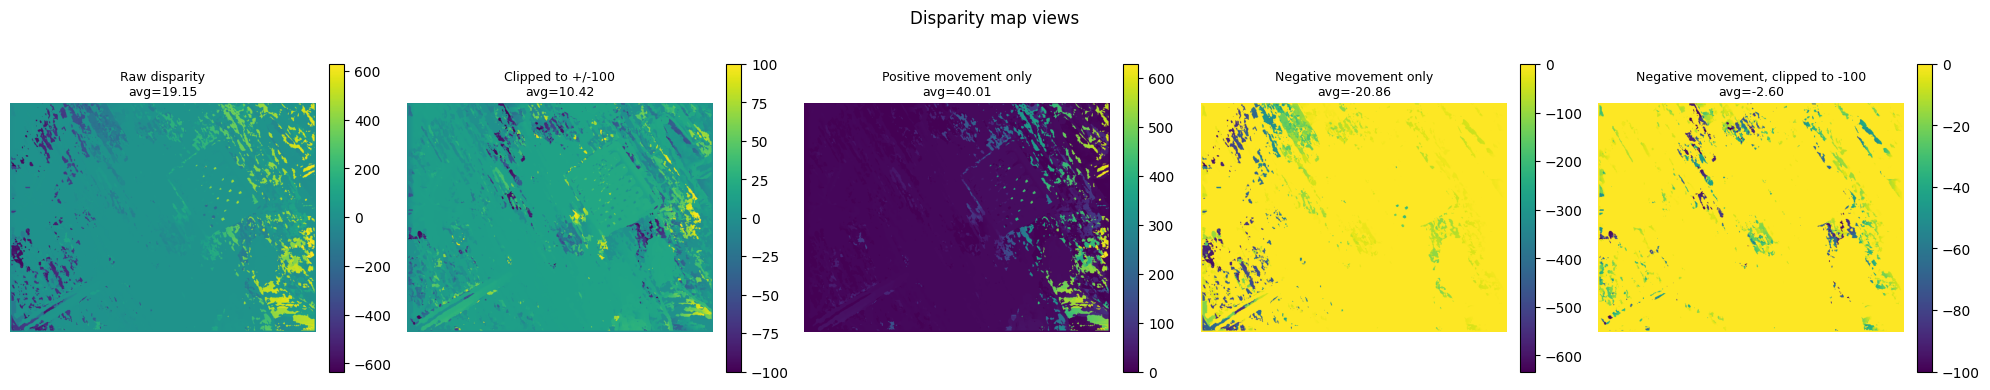

In [52]:
result = disparity(rectified_l, rectified_r)
plot_disparity_views(result)

## Dataset 2: MYNT EYE

Same code, wider lenses and 1280x720.

In [53]:
ds = '../data/week_4/mynteye'
ret_stereo, mtx_l, dist_l, mtx_r, dist_r, R, T, E, F = calibrate_stereo(9, 6, ds)
print(f"Overall RMS: {ret_stereo}")
shape = get_image_shape(ds)

new_camera_matrix_l, roi_l = cv2.getOptimalNewCameraMatrix(mtx_l, dist_l, shape, 1, shape)
new_camera_matrix_r, roi_r = cv2.getOptimalNewCameraMatrix(mtx_r, dist_r, shape, 1, shape)


print(f"New camera matrix l {new_camera_matrix_l}\n roi_l {roi_l}")
print(f"New camera matrix r {new_camera_matrix_r}\n roi_l {roi_r}")

Corners found in 50 image pairs
Overall RMS: 0.3165073673164786
New camera matrix l [[281.86719096   0.         593.68368401]
 [  0.         323.99926547 338.60810674]
 [  0.           0.           1.        ]]
 roi_l (345, 167, 512, 331)
New camera matrix r [[9.58937205e+01 0.00000000e+00 1.11137018e+03]
 [0.00000000e+00 1.20912907e+02 6.10386341e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
 roi_l (1023, 546, 175, 124)


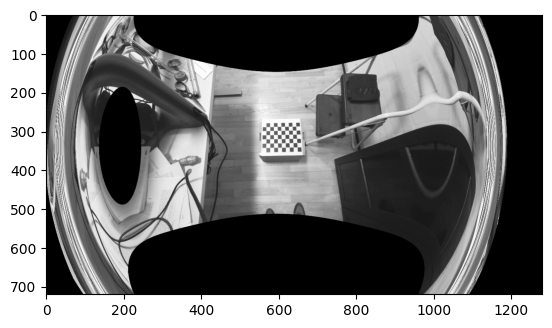

In [54]:
img_left = cv2.imread(f'{ds}/left-0000.png', cv2.IMREAD_GRAYSCALE)
img_right = cv2.imread(f'{ds}/right-0000.png', cv2.IMREAD_GRAYSCALE)

dst_l = cv2.undistort(img_left, mtx_l, dist_l, None, new_camera_matrix_l)
dst_r = cv2.undistort(img_right, mtx_r, dist_r, None, new_camera_matrix_r)

plt.imshow(dst_l, cmap='gray')

In [55]:

R1, R2, P1, P2, Q, roi_l, roi_r = cv2.stereoRectify(
    mtx_l, dist_l, mtx_r, dist_r, shape, R, T,
    flags=cv2.CALIB_ZERO_DISPARITY, alpha=0
)

map_l_x, map_l_y = cv2.initUndistortRectifyMap(mtx_l, dist_l, R1, P1, shape, cv2.CV_32FC1)
map_r_x, map_r_y = cv2.initUndistortRectifyMap(mtx_r, dist_r, R2, P2, shape, cv2.CV_32FC1)

In [56]:
rectified_l = cv2.remap(img_left, map_l_x, map_l_y, cv2.INTER_LINEAR)
rectified_r = cv2.remap(img_right, map_r_x, map_r_y, cv2.INTER_LINEAR)

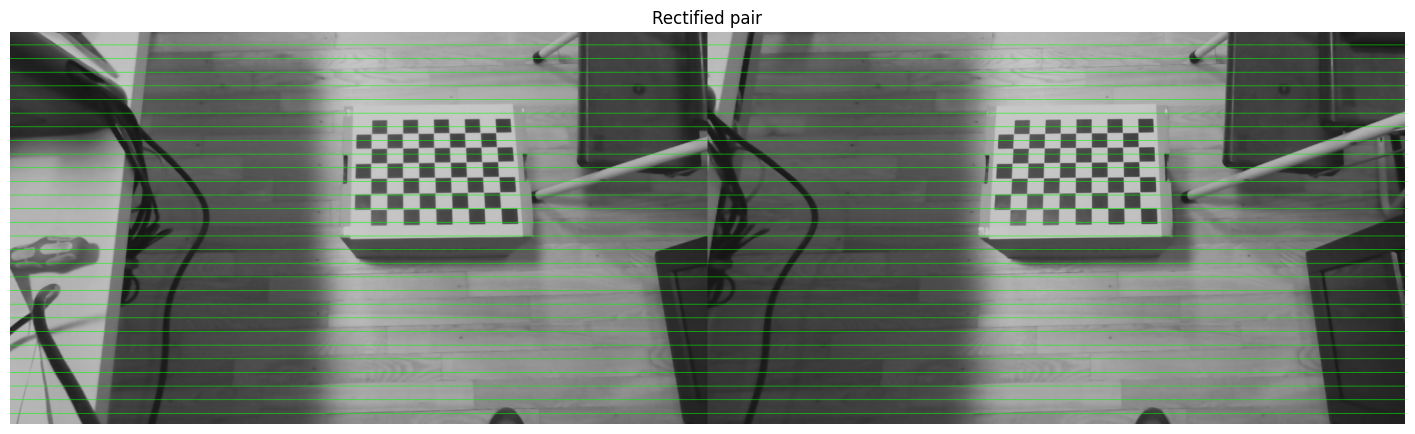

In [41]:
stacked = np.hstack((rectified_l, rectified_r))
stacked_bgr = cv2.cvtColor(stacked, cv2.COLOR_GRAY2BGR)

for y in range(0, stacked_bgr.shape[0], 25):
    cv2.line(stacked_bgr, (0, y), (stacked_bgr.shape[1], y), (0, 255, 0), 1)

plt.figure(figsize=(18, 9))
plt.imshow(stacked_bgr[..., [2, 1, 0]])
plt.title("Rectified pair")
plt.axis('off')
plt.show()

### Conclusion

0.19 px calibration, a rectification that passes the epipolar check and a disparity map with the right depth structure. By running the same code unchanged on a second rig with different lenses and resolution, we ensure a proper comparison between the two datasets.

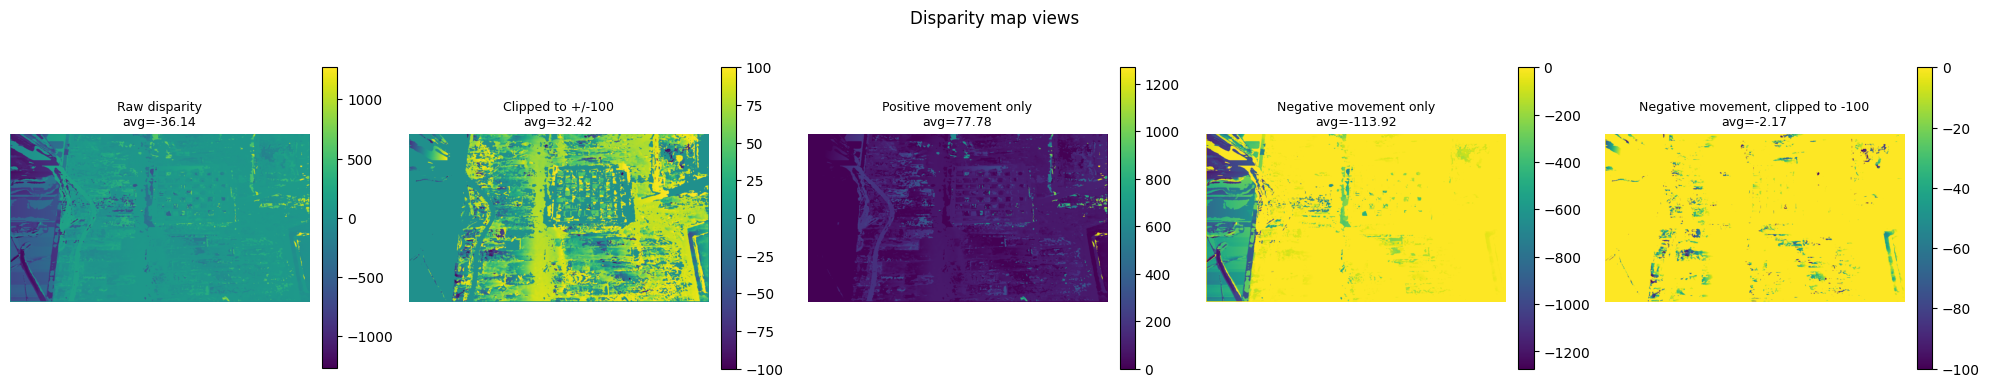

In [57]:
result = disparity(rectified_l, rectified_r)
plot_disparity_views(result)